In [6]:
!pip install yfinance

In [7]:
import yfinance as yf
import pandas as pd

# JPY/KRW 월별(1mo) 데이터 다운로드 (2000년 1월 1일 ~ 현재)
# progress=False는 다운로드 진행바를 숨겨서 결과를 깔끔하게 만듭니다.
df_exchange = yf.download('JPYKRW=X', start='2000-01-01', interval='1mo', progress=False)

# 인덱스(Date)를 보기 편하게 조정하고 앞의 5줄 확인
df_exchange = df_exchange.reset_index()
df_exchange.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,JPYKRW=X,JPYKRW=X,JPYKRW=X,JPYKRW=X,JPYKRW=X
0,2003-12-01,11.091,11.226,10.795,10.900,0
1,2004-01-01,11.076,11.252,10.855,11.091,0
2,2004-02-01,10.722,11.187,10.554,11.076,0
3,2004-03-01,11.188,11.264,10.331,10.716,0
4,2004-04-01,10.531,11.386,10.339,11.190,0


In [8]:
# 판다스 도구 불러오기 (파이썬에게 pd가 뭔지 알려주기)
import pandas as pd

# 엑셀 파일 불러오기
df_tourist = pd.read_excel('data/tourists_to_japan.xlsx')

# 데이터가 어떻게 생겼는지 앞의 10줄만 확인하기
df_tourist.head(10)

,Month (abbr),Year,Country/Area,집계(Growth Rate(%)),합계(Visitor Arrivals)
0,Dec.,2000,Vietnam,744.943820,752.0
1,Nov.,2000,Vietnam,766.956522,997.0
2,Oct.,2000,Vietnam,327.131783,1102.0
3,Sep.,2000,Vietnam,534.567901,1028.0
4,Aug.,2000,Vietnam,232.034632,767.0
5,Jul.,2000,Vietnam,597.260274,1018.0
6,Jun.,2000,Vietnam,586.363636,755.0
7,May,2000,Vietnam,450.000000,715.0
8,Apr.,2000,Vietnam,470.860927,862.0
9,Mar.,2000,Vietnam,415.573770,629.0


In [9]:
# 1. 'South Korea' 데이터만 필터링 (한국 관광객만 쏙 빼오기)
df_korea = df_tourist[df_tourist['Country/Area'] == 'South Korea'].copy()

# 2. Year와 Month를 합쳐서 'Date'라는 새로운 날짜 컬럼 만들기
# (pandas가 똑똑해서 '2000 Dec.'을 '2000-12-01' 형태의 진짜 날짜로 바꿔줍니다)
df_korea['Date'] = pd.to_datetime(df_korea['Year'].astype(str) + ' ' + df_korea['Month (abbr)'])

# 3. 필요한 컬럼(날짜, 방문객 수)만 남기고 이름 직관적으로 바꾸기
df_korea = df_korea[['Date', '합계(Visitor Arrivals)']]
df_korea.columns = ['Date', 'Visitors'] # Visitors: 방문객 수

# 4. 날짜를 기준으로 과거에서 최신 순으로 정렬하기
df_korea = df_korea.sort_values('Date').reset_index(drop=True)

# 예쁘게 다듬어진 데이터 앞의 5줄 확인하기!
df_korea.head()

C:\Users\u\AppData\Local\Temp\ipykernel_16304\3378623148.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_korea['Date'] = pd.to_datetime(df_korea['Year'].astype(str) + ' ' + df_korea['Month (abbr)'])


,Date,Visitors
0,2000-01-01,93768.0
1,2000-02-01,78040.0
2,2000-03-01,80549.0
3,2000-04-01,84484.0
4,2000-05-01,81409.0


In [ ]:
# 파이썬이 잊어버린 환율 데이터 빠르게 다시 가져오기
import yfinance as yf
df_exchange = yf.download('JPYKRW=X', start='2014-01-01', interval='1mo', progress=False)
df_exchange = df_exchange.reset_index()

# 1. 환율 데이터에서 필요한 컬럼(날짜, 종가)만 가져와서 이름 알기 쉽게 변경
df_ex_subset = df_exchange[['Date', 'Close']].copy()
df_ex_subset.columns = ['Date', 'Exchange_Rate'] # Close(종가)를 Exchange_Rate(환율)로 변경

# 2. 두 데이터를 'Date' 기준으로 병합 (how='inner'는 교집합만 남긴다는 뜻!)
df_merged = pd.merge(df_korea, df_ex_subset, on='Date', how='inner')

# 3. 과제 요구사항: 데이터 기본 정보 및 결측치(비어있는 값) 확인
print("=== 병합된 데이터 정보 ===")
df_merged.info()
print("\n=== 결측치(빈칸) 확인 ===")
print(df_merged.isnull().sum())

# 4. 최종 완성된 데이터 앞 5줄 확인
df_merged.head()

=== 병합된 데이터 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           153 non-null    datetime64[us]
 1   Visitors       149 non-null    float64       
 2   Exchange_Rate  153 non-null    float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 3.7 KB

=== 결측치(빈칸) 확인 ===
Date             0
Visitors         4
Exchange_Rate    0
dtype: int64


,Date,Visitors,Exchange_Rate
0,2014-01-01,255517.0,10.502
1,2014-02-01,231502.0,10.468
2,2014-03-01,192078.0,10.388
3,2014-04-01,193998.0,10.032
4,2014-05-01,195263.0,10.018


In [12]:
# 1. 빈칸(결측치)이 있는 데이터 눈으로 확인하기
print("=== 결측치(빈칸)가 있는 달 확인 ===")
print(df_merged[df_merged['Visitors'].isnull()])

# 2. 결측치 처리: 방문객 통계가 없는 행은 삭제(dropna)하고 순서 다시 맞추기
df_clean = df_merged.dropna().reset_index(drop=True)

# 3. 결측치 청소 후 최종 상태 확인
print("\n=== 결측치 처리 완료! ===")
print(f"최종 확보된 데이터: 총 {len(df_clean)}개월 치")
print(df_clean.isnull().sum())

=== 결측치(빈칸)가 있는 달 확인 ===
          Date  Visitors  Exchange_Rate
149 2026-06-01       NaN       9.520466
150 2026-07-01       NaN       8.867804
151 2026-08-01       NaN       8.600559
152 2026-09-01       NaN       8.798000

=== 결측치 처리 완료! ===
최종 확보된 데이터: 총 149개월 치
Date             0
Visitors         0
Exchange_Rate    0
dtype: int64


   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------------- -------------------------- 3.1/9.3 MB 15.8 MB/s eta 0:00:01
   ------------------------------ --------- 7.1/9.3 MB 16.5 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 15.4 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 13.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   -------------------------------------- - 2.4/2.5 MB 15.9 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 10.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------------------- ------------------- 3.7/7.2 MB 17.7 MB/s eta 0:00:01
   ---------------------------------------  7.1/7.2 MB 17.2 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 14.0 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 

Matplotlib is building the font cache; this may take a moment.


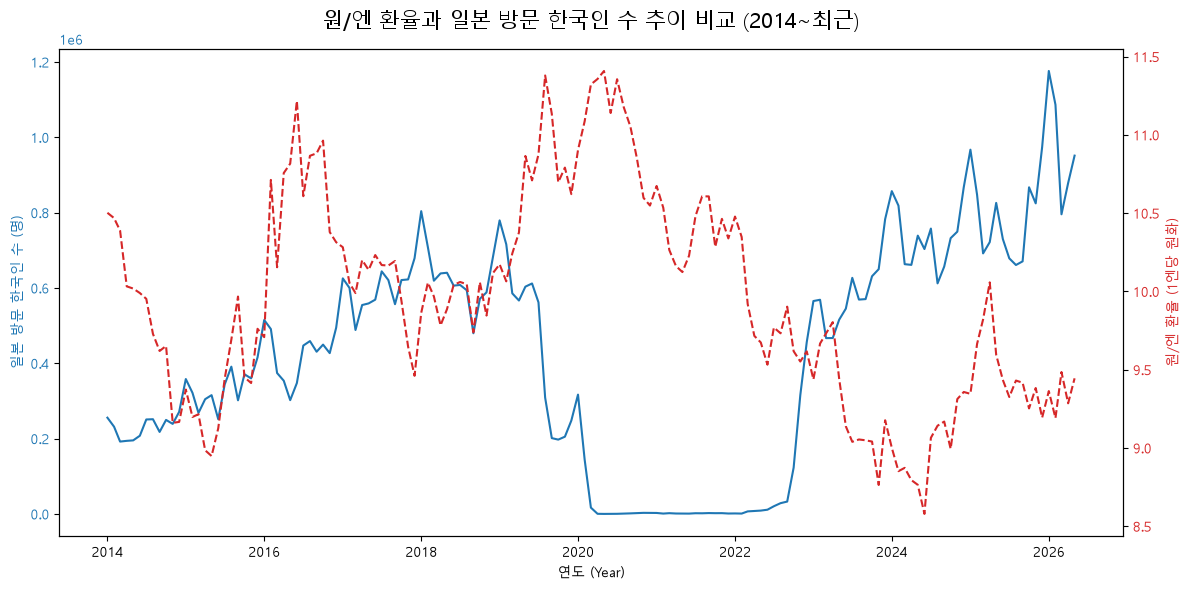

In [15]:
# 그래프를 그리기 위한 도구(matplotlib) 설치하기
!pip install matplotlib

import matplotlib.pyplot as plt

# 한글 폰트 깨짐 방지 설정 (Windows 기준 'Malgun Gothic')
# 만약 Mac을 사용 중이시라면 'Malgun Gothic' 대신 'AppleGothic'으로 변경해 주세요!
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 1. 도화지(Figure) 준비
fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. 첫 번째 축 (왼쪽 y축): 방문객 수 (파란색 실선)
color1 = 'tab:blue'
ax1.set_xlabel('연도 (Year)')
ax1.set_ylabel('일본 방문 한국인 수 (명)', color=color1)
ax1.plot(df_clean['Date'], df_clean['Visitors'], color=color1, label='방문객 수')
ax1.tick_params(axis='y', labelcolor=color1)

# 3. 두 번째 축 (오른쪽 y축): 원/엔 환율 (빨간색 점선)
ax2 = ax1.twinx()  # x축을 공유하는 두 번째 y축 생성
color2 = 'tab:red'
ax2.set_ylabel('원/엔 환율 (1엔당 원화)', color=color2)
ax2.plot(df_clean['Date'], df_clean['Exchange_Rate'], color=color2, linestyle='--', label='환율')
ax2.tick_params(axis='y', labelcolor=color2)

# 4. 제목 달고 이미지로 저장하기
plt.title('원/엔 환율과 일본 방문 한국인 수 추이 비교 (2014~최근)', fontsize=15, pad=15)
fig.tight_layout() # 글자나 축이 잘리지 않게 여백 자동 조정

# 이미지를 폴더에 저장 (과제 리포트 작성용)
plt.savefig('images/01_trend_dual_axis.png')

# 화면에 그래프 출력
plt.show()

C:\Users\u\AppData\Local\Temp\ipykernel_19964\3091691891.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_korea['Date'] = pd.to_datetime(df_korea['Year'].astype(str) + ' ' + df_korea['Month (abbr)'])


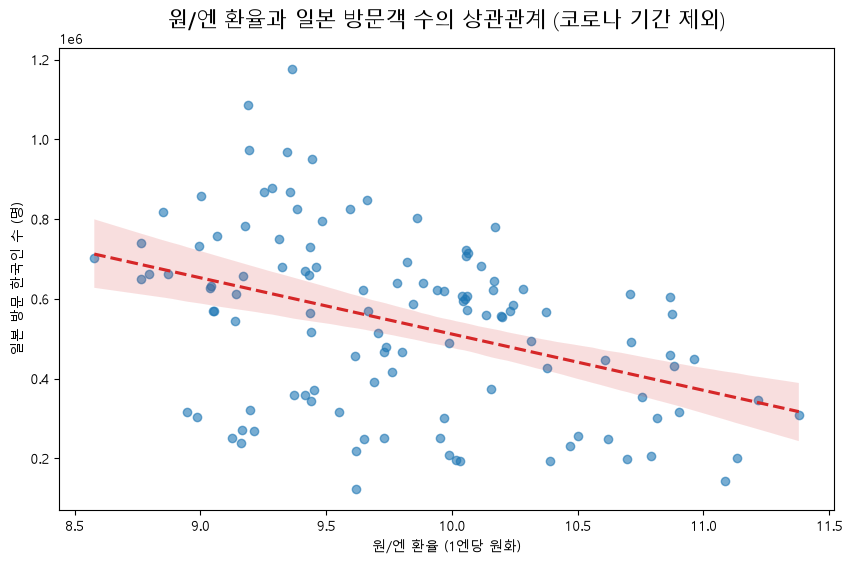

In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# [1단계] 파이썬의 기억 되살리기 (데이터 빠르게 다시 준비)
# ---------------------------------------------------------
# 환율 데이터 다시 가져오기
df_exchange = yf.download('JPYKRW=X', start='2014-01-01', interval='1mo', progress=False).reset_index()
df_ex_subset = df_exchange[['Date', 'Close']].copy()
df_ex_subset.columns = ['Date', 'Exchange_Rate']

# 여행객 데이터 다시 가져오기 및 한국만 필터링
df_tourist = pd.read_excel('data/tourists_to_japan.xlsx')
df_korea = df_tourist[df_tourist['Country/Area'] == 'South Korea'].copy()
df_korea['Date'] = pd.to_datetime(df_korea['Year'].astype(str) + ' ' + df_korea['Month (abbr)'])
df_korea = df_korea[['Date', '합계(Visitor Arrivals)']]
df_korea.columns = ['Date', 'Visitors']

# 두 데이터 합치고 빈칸(결측치) 지우기 -> df_clean 부활!
df_merged = pd.merge(df_korea, df_ex_subset, on='Date', how='inner')
df_clean = df_merged.dropna().reset_index(drop=True)

# ---------------------------------------------------------
# [2단계] 이상치 처리 및 산점도 그리기
# ---------------------------------------------------------
# 과제 요구사항: 이상치 처리 (코로나19 기간 제외)
df_normal = df_clean[(df_clean['Date'] < '2020-03-01') | (df_clean['Date'] > '2022-09-01')]

# 폰트 깨짐 방지
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 그래프 그리기
plt.figure(figsize=(10, 6))
sns.regplot(x='Exchange_Rate', y='Visitors', data=df_normal, 
            scatter_kws={'alpha':0.6, 'color':'tab:blue'}, 
            line_kws={'color':'tab:red', 'linestyle':'--'})

plt.title('원/엔 환율과 일본 방문객 수의 상관관계 (코로나 기간 제외)', fontsize=15, pad=15)
plt.xlabel('원/엔 환율 (1엔당 원화)')
plt.ylabel('일본 방문 한국인 수 (명)')

# 이미지 폴더에 저장
plt.savefig('images/02_scatter_correlation.png')

plt.show()

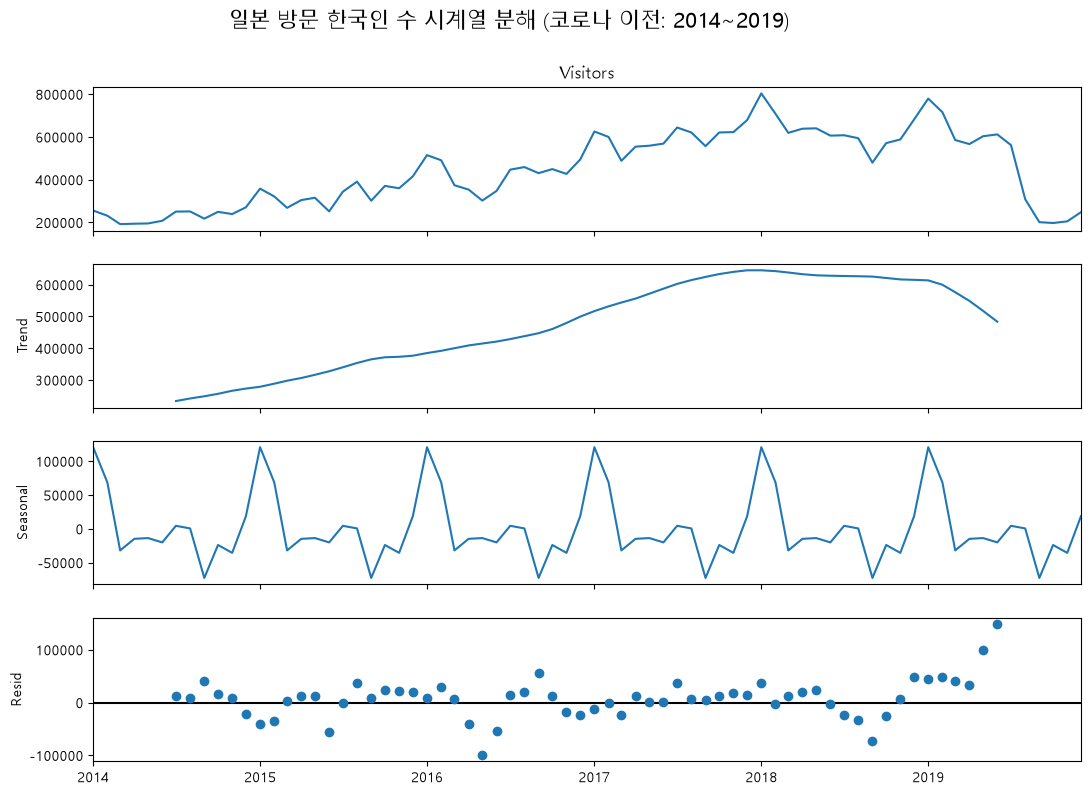

In [5]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. 코로나 이전(2014~2019년) 데이터만 잘라내기
df_pre_covid = df_clean[df_clean['Date'] < '2020-01-01'].copy()

# 시계열 분석을 위해 'Date' 컬럼을 인덱스로 설정
df_pre_covid.set_index('Date', inplace=True) 

# ★ 핵심 추가: 날짜 순으로 완벽하게 오름차순 정렬하기 ★
df_pre_covid.sort_index(inplace=True)

# 2. 시계열 분해 (12개월 주기로 패턴 분리)
decomposition = sm.tsa.seasonal_decompose(df_pre_covid['Visitors'], model='additive', period=12)

# 3. 분해된 4가지 그래프 한 번에 그리기
fig = decomposition.plot()
fig.set_size_inches(12, 8)

# 폰트 깨짐 방지
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 제목 및 저장
plt.suptitle('일본 방문 한국인 수 시계열 분해 (코로나 이전: 2014~2019)', fontsize=15, y=1.02)
plt.savefig('images/03_time_series_decomposition.png')
plt.show()

C:\Users\u\AppData\Local\Temp\ipykernel_19964\3737800152.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='Visitors', data=df_pre_covid, palette='Blues')


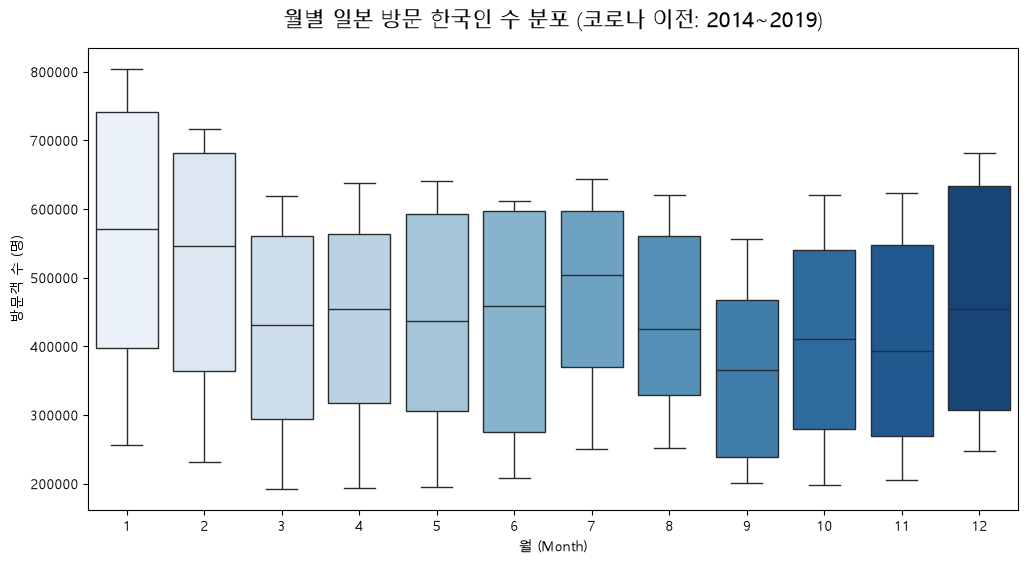

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 시계열 분해에 썼던 '코로나 이전(2014~2019)' 데이터를 그대로 활용
# 데이터의 날짜(Index)에서 '월(Month)' 정보만 따로 뽑아서 새로운 컬럼 만들기
df_pre_covid['Month'] = df_pre_covid.index.month

# 2. 폰트 깨짐 방지
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 3. 월별 분포를 보여주는 박스플롯 그리기
plt.figure(figsize=(12, 6))

# palette='Blues'로 파란색 그라데이션을 줘서 예쁘게 꾸미기
sns.boxplot(x='Month', y='Visitors', data=df_pre_covid, palette='Blues')

# 제목 및 라벨 달기
plt.title('월별 일본 방문 한국인 수 분포 (코로나 이전: 2014~2019)', fontsize=15, pad=15)
plt.xlabel('월 (Month)')
plt.ylabel('방문객 수 (명)')

# 이미지 폴더에 저장 (리포트 추가용)
plt.savefig('images/04_monthly_boxplot.png')

plt.show()